# Exploratory Data Analysis

In [24]:
import pandas as pd
import ast
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")

In [25]:
pcl = pd.read_csv(
    DATA_DIR / "dontpatronizeme_pcl.tsv",
    sep="\t",
    header=None,
    names=["id", "par_id", "keyword", "country", "text", "category"],
)
pcl["id"] = pcl["id"].astype(int)
pcl.head(3)

,id,par_id,keyword,country,text,category
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0


In [26]:
train_labels = pd.read_csv(DATA_DIR / "train_semeval_parids-labels.csv")

def to_binary(label_str):
    vec = ast.literal_eval(label_str)
    return 1 if any(x == 1 for x in vec) else 0

train_labels["binary_label"] = train_labels["label"].apply(to_binary)
train_labels[["par_id", "binary_label"]].head(10)

,par_id,binary_label
0,4341,1
1,4136,1
2,10352,1
3,8279,1
4,1164,1
5,7568,1
6,6027,1
7,9343,1
8,1231,1
9,911,1


In [27]:

train_df = pcl[pcl["id"].isin(train_labels["par_id"])].copy()
train_df = train_df.merge(
    train_labels[["par_id", "binary_label"]],
    left_on="id",
    right_on="par_id",
    how="inner",
)
train_df = train_df[["id", "text", "binary_label"]]
print(f"Training examples: {len(train_df)}")
train_df.head()

Training examples: 8375


,id,text,binary_label
0,1,"We 're living in times of absolute insanity , ...",0
1,2,"In Libya today , there are countless number of...",0
2,3,White House press secretary Sean Spicer said t...,0
3,4,Council customers only signs would be displaye...,0
4,5,""" Just like we received migrants fleeing El Sa...",0


## EDA Technique 1: Class distribution

We analyse the balance of PCL (1) vs No PCL (0) in the training set. Imbalance matters because the task is evaluated with F1 score of the positive class (PCL), not accuracy.

In [28]:
counts = train_df["binary_label"].value_counts().sort_index()
pcts = train_df["binary_label"].value_counts(normalize=True).sort_index() * 100

class_names = ["No PCL (0)", "PCL (1)"]
dist_table = pd.DataFrame({
    "Class": class_names,
    "Count": [counts.get(0, 0), counts.get(1, 0)],
    "Percentage (%)": [round(pcts.get(0, 0), 1), round(pcts.get(1, 0), 1)],
})
dist_table

,Class,Count,Percentage (%)
0,No PCL (0),7581,90.5
1,PCL (1),794,9.5


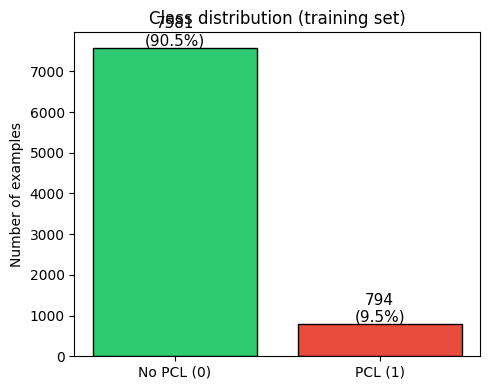

In [29]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_names, [counts.get(0, 0), counts.get(1, 0)], color=["#2ecc71", "#e74c3c"], edgecolor="black")
ax.set_ylabel("Number of examples")
ax.set_title("Class distribution (training set)")
for i, (c, p) in enumerate(zip([counts.get(0, 0), counts.get(1, 0)], [pcts.get(0, 0), pcts.get(1, 0)])):
    ax.text(i, c + 50, f"{c}\n({p:.1f}%)", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

**Analysis:** The training set is imbalanced: the majority class (No PCL) has many more examples than the positive class (PCL). A classifier that always predicts the majority class would achieve high accuracy but zero F1 on the positive class.

Because the coursework evaluates positive-class F1, this imbalance motivates using class weighting (e.g. in the loss), resampling (oversampling PCL or undersampling No PCL), or threshold tuning at prediction time, rather than relying on raw accuracy or default decision thresholds.